# Exhibit: Forecasting Inflation When the World Changes

*Workshop exhibit — **Structural Change and Expectations in Macroeconomics and Finance** (University of Copenhagen, Autumn 2026).*

## 1. The question

If the inflation process undergoes structural breaks — and by now you have seen the evidence that it does — then a forecasting model faces a dilemma. Use *all* the data, and your estimates average over regimes that no longer apply. Use only *recent* data, and your estimates are noisy. Atkeson and Ohanian (2001) made the dilemma famous: during the Great Moderation, sophisticated inflation-forecasting models could not beat the naive rule "next year = past year."

So: **does accounting for structural breaks produce better forecasts?** The subtle part of that question is *what the forecaster is allowed to know*. We build a ladder of forecasters that differ **only in their information about the breaks**:

1. **Constant AR** — an AR(1) for quarterly inflation, estimated on *all* past data. Never adapts.
2. **Rolling AR** — the same AR(1), estimated on the last 40 quarters only. Adapts by *forgetting*, without ever knowing where the breaks are.
3. **Oracle AR** — the same AR(1), estimated only on data since the most recent break — with the break dates **handed down ex post** (estimated on the full sample with a Bai–Perron-type procedure). Not a feasible real-time forecaster: an *upper bound* on what break-accounting could deliver.
4. **The naive rule** — next year's inflation = the past year's (the Atkeson–Ohanian benchmark).
5. **The SPF** — the professional forecasters, as the human reference.

All five obey the **real-time rule**: to forecast at quarter $t$, only data through $t$ may be used — the oracle cheats *only* on the break dates, never on the data.

The gaps between the rungs are the point: oracle-minus-constant is what breaks cost the full-sample model; **oracle-minus-rolling is the price of not knowing the break dates**. And evaluating the race honestly runs into the same problem the forecasters face: in a changing world, *which forecaster is best is itself regime-dependent* — so we evaluate by era and with rolling measures, never with one full-sample number alone.

**Data:** quarterly US GDP-deflator inflation (first release) and the SPF, 1968–2024 — the Workshop 1 dataset. The forecast target is the same object throughout: **average quarterly inflation over the next four quarters**. Oracle break dates (estimated ex post on an AR(1) for inflation): 1973Q1, 1975Q4, 1978Q4, 1982Q1, 1991Q3, 2020Q3.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, RED, TEAL, GREY = "#006BA2", "#DB444B", "#3EBCD2", "#758D99"
ORANGE = "#EB8100"
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.35,
    "axes.titlelocation": "left", "axes.titlesize": 12, "font.size": 11,
})

def load(name):
    try:
        df = pd.read_csv(f"../data/{name}", index_col="quarter")
    except FileNotFoundError:
        base = "https://raw.githubusercontent.com/mortentabor/structural-change-seminar/main/data/"
        df = pd.read_csv(base + name, index_col="quarter")
    df.index = pd.PeriodIndex(df.index, freq="Q")
    return df

pi = load("inflation_quarterly.csv")["inflation"]
fe = load("forecast_errors.csv").dropna(subset=["pi_avg", "F_avg", "pi_lag"])

BREAKS = [pd.Period(b, freq="Q") for b in
          ["1973Q1", "1975Q4", "1978Q4", "1982Q1", "1991Q3", "2020Q3"]]

## 2. Building the five forecasters

One helper does the model work: fit an AR(1) on whatever history it is given, iterate the forecast four quarters ahead, and average — so every AR forecaster produces the same *object* as the SPF and the naive rule. The three AR forecasters differ only in **which history they hand to the helper**.

In [2]:
def ar1_forecast_avg(series):
    """Fit an AR(1) on `series`; iterate 4 steps ahead; return the average forecast."""
    y = series.values
    if len(y) < 8:
        return None
    X = np.column_stack([np.ones(len(y) - 1), y[:-1]])
    (c, phi), *_ = np.linalg.lstsq(X, y[1:], rcond=None)
    f, last = [], y[-1]
    for _ in range(4):
        last = c + phi * last
        f.append(last)
    return float(np.mean(f))

WINDOW = 40        # rolling window (quarters) — try 20, then 60
MIN_REGIME = 8     # minimum observations the oracle demands in a young regime

rows = []
for t in fe.index[fe.index >= "1975Q1"]:
    hist = pi.loc[:t].dropna()
    if len(hist) < 12:
        continue
    past_breaks = [b for b in BREAKS if b <= t]
    regime = hist.loc[past_breaks[-1]:] if past_breaks else hist
    if len(regime) < MIN_REGIME:            # a young regime: too little data —
        regime = hist.iloc[-MIN_REGIME:]    # fall back to the last MIN_REGIME quarters
    rows.append({
        "quarter": t,
        "actual": fe.loc[t, "pi_avg"],
        "const": ar1_forecast_avg(hist),
        "roll": ar1_forecast_avg(hist.iloc[-WINDOW:]),
        "oracle": ar1_forecast_avg(regime),
        "naive": fe.loc[t, "pi_lag"],
        "spf": fe.loc[t, "F_avg"],
    })
fc = pd.DataFrame(rows).set_index("quarter").dropna()
print(f"Evaluation sample: {fc.index.min()}\u2013{fc.index.max()}  (n = {len(fc)})")
fc.tail(3).round(2)

Evaluation sample: 1975Q1–2024Q2  (n = 198)


,actual,const,roll,oracle,naive,spf
quarter,,,,,,
2023Q4,2.36,2.21,2.09,3.18,1.48,2.14
2024Q1,2.52,3.23,2.86,3.98,3.12,2.56
2024Q2,2.44,2.71,2.50,3.45,2.28,2.38


## 3. The horse race

RMSE over the full evaluation window — and by era, because a single full-sample number can hide everything that matters. **Change the eras** (edit the dictionary, rerun): where does each forecaster win?

In [3]:
MODELS = ["const", "roll", "oracle", "naive", "spf"]

ERAS = {
    "Full 1975\u20132024":  ("1975Q1", "2024Q2"),
    "1975\u20131979":       ("1975Q1", "1979Q4"),
    "Great Moderation":     ("1980Q1", "2019Q4"),
    "Post-2020":            ("2020Q1", "2024Q2"),
}

def rmse(d, col):
    return float(np.sqrt(np.mean((d["actual"] - d[col]) ** 2)))

table = pd.DataFrame({era: {m: rmse(fc.loc[s:e], m) for m in MODELS}
                      for era, (s, e) in ERAS.items()}).T
table.round(2)

,const,roll,oracle,naive,spf
Full 1975–2024,1.36,1.33,1.38,1.28,1.00
1975–1979,1.55,1.54,2.03,1.39,1.11
Great Moderation,1.27,1.06,0.92,1.07,0.72
Post-2020,1.87,2.65,2.97,2.37,2.26


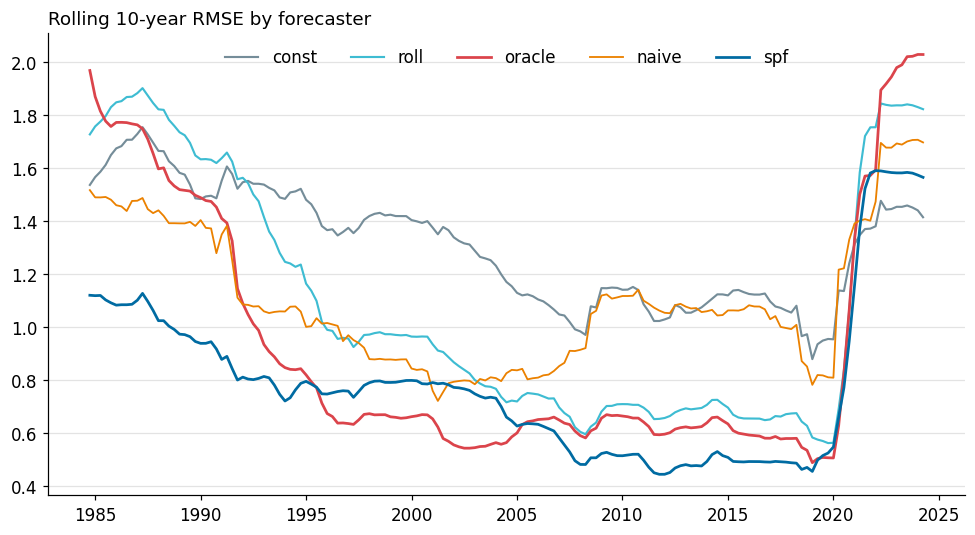

In [4]:
# Rolling 10-year RMSE: the continuous view of who is winning, when
styles = {"const": (GREY, 1.4), "roll": (TEAL, 1.4), "oracle": (RED, 1.8),
          "naive": (ORANGE, 1.2), "spf": (BLUE, 1.8)}
fig, ax = plt.subplots(figsize=(9, 5))
for m, (color, lw) in styles.items():
    r = (fc["actual"] - fc[m]).pow(2).rolling(40).mean().pow(0.5)
    ax.plot(fc.index.to_timestamp(), r, color=color, lw=lw, label=m)
ax.set_title("Rolling 10-year RMSE by forecaster")
ax.legend(frameon=False, ncol=5)
plt.tight_layout()
plt.show()

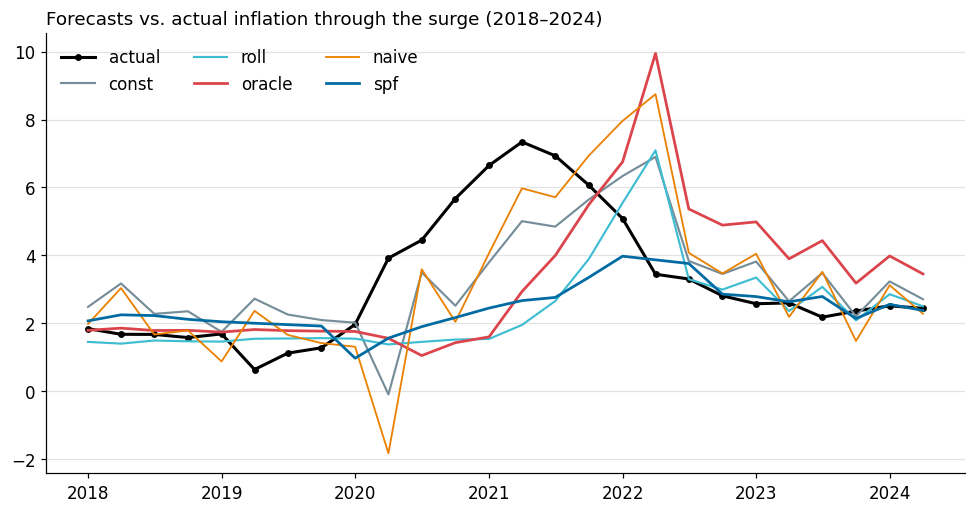

In [5]:
# Zoom: the forecasters through the post-2020 surge
zoom = fc.loc["2018Q1":]
fig, ax = plt.subplots(figsize=(9, 4.8))
x = zoom.index.to_timestamp()
ax.plot(x, zoom["actual"], color="black", lw=2, marker="o", ms=3.5, label="actual")
for m, (color, lw) in styles.items():
    ax.plot(x, zoom[m], color=color, lw=lw, label=m)
ax.set_title("Forecasts vs. actual inflation through the surge (2018\u20132024)")
ax.legend(frameon=False, ncol=3)
plt.tight_layout()
plt.show()

## 4. Reading the ladder — the surprise

If break-accounting simply paid off, the ranking would be oracle ≤ rolling ≤ constant. Look at the table. It is not:

- Over the **full window**, the oracle — with perfect ex-post knowledge of the break dates — is the *worst* of the three AR forecasters.
- In the **Great Moderation**, the oracle is the *best* model: knowing the 1991 break and then enjoying thirty stable years is exactly when regime knowledge pays.
- **Post-2020**, the ranking turns upside down: the *constant* AR — the model that adapts least — beats everyone, **including the professional forecasters**.

Why does the oracle fail? Look at the zoom figure: right after a break, the oracle (and the rolling model) estimate on a handful of turbulent observations and swing wildly, while the constant model's long memory quietly assumes the spike will mean-revert — which, this time, it did. **Knowing *where* the breaks are is not knowing the new regime's *parameters*: a fresh regime arrives with almost no data about itself.** Ex-post dates are not ex-ante knowledge — and even ex-post dates, this exercise shows, are less valuable than they look.

Three honest conclusions:

1. **No forecaster dominates.** Which model is "best" is regime-dependent — so any evaluation over a single window quietly picks a winner by picking a window.
2. **The value of break-accounting depends on regime length**: it pays in long stable regimes and hurts in young ones. Fast adaptation and reliable estimation pull in opposite directions.
3. And remember: the oracle is an *upper bound*. A real-time forecaster must also **detect** the break — with a lag, from noisy data. That problem is Workshop 3.

**Try it yourself:** raise `MIN_REGIME` (the oracle waits longer before trusting a young regime) or change `WINDOW`, rerun Sections 2–3 — can you find a break-aware forecaster that beats the constant AR post-2020?

## 5. What could a paper deliver?

You have now seen that break-accounting is no free lunch. **That, by itself, is not yet a research question.** Four types of questions you can build:

1. **Timing / episodes** — *when* does each forecaster win and lose? Are the reversals concentrated at the break episodes — and are they the same episodes where the SPF's errors turned systematic (Workshop 1)?
2. **Source / mechanism** — *why* does the constant AR win post-2020: the mean-reversion assumption, the long memory, or luck? Decompose the errors.
3. **Interpretation / inference** — what is a forecast evaluation worth when rankings flip across regimes? How should we compare forecasters in a changing world?
4. **Consequences / practice** — can *real-time* break detection close any of the oracle gap? Detect breaks recursively and feed the dates to the forecaster — the honest version of this exhibit's oracle.

**A concrete tool for question 4 that you already know:** in Econometrics II you worked with **OxMetrics**. Its **Autometrics** algorithm with **step-indicator saturation (SIS)** and **multiplicative-indicator saturation (MIS)** detects breaks in a model automatically — in intercepts (SIS) and in slopes (MIS). Running SIS/MIS recursively and letting the detected breaks drive the forecasts is a genuine, feasible seminar paper — and an open research question.

**The "This paper…" exercise.** A research question is specific when you can state what the paper *delivers*:

> *Weak:* "This paper examines whether break-adjusted models forecast better."
>
> *Strong:* "This paper shows that even with perfect knowledge of the break dates, break-adjusted AR forecasts lose to a constant-parameter model after 2020 — and asks how long a new regime must last before knowing about it pays."

**Your task:** write one or two **"This paper…"** sentences for this exhibit.

## 6. Further reading

- Atkeson, A., and Ohanian, L. (2001). "Are Phillips Curves Useful for Forecasting Inflation?" *Federal Reserve Bank of Minneapolis Quarterly Review*, 25(1) — the naive-benchmark tradition this exhibit extends.
- Rossi, B. (2021). "Forecasting in the Presence of Instabilities." *Journal of Economic Literature*, 59(4) — the survey of exactly this exhibit's question.
- Pesaran, M. H., and Timmermann, A. (2007). "Selection of Estimation Window in the Presence of Breaks." *Journal of Econometrics*, 137(1) — the young-regime trade-off made precise.
- Castle, J., Clements, M., and Hendry, D. (2015). "Robust Approaches to Forecasting." *International Journal of Forecasting*, 31(1) — what to do after a break when you cannot estimate the new regime.
- Faust, J., and Wright, J. (2013). "Forecasting Inflation." In *Handbook of Economic Forecasting*, Vol. 2 — what actually works, and why simple devices rank high.